In [18]:
# Import libraries
import os
from tensorflow import keras
import pandas as pd
import numpy as np
import tensorflow as tf
import tarfile
import urllib.request
import shutil
import matplotlib.pyplot as plt

## 1.1 *(0.5 points)* Preprocess the dataset and formulate the edge prediction task. 

In [19]:
# Paths and URLs
url = "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz"
base_dir = os.path.expanduser("~/cora_dataset")
tgz_path = os.path.join(base_dir, "cora.tgz")
cora_dir = os.path.join(base_dir, "cora")
cites_file = os.path.join(cora_dir, "cora.cites")
content_file = os.path.join(cora_dir, "cora.content")

# Download dataset
os.makedirs(base_dir, exist_ok=True)
if not os.path.exists(tgz_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, tgz_path)

# Extract dataset
if not os.path.exists(cora_dir):
    print("Extracting dataset...")
    with tarfile.open(tgz_path, "r:gz") as tar:
        tar.extractall(path=base_dir)

# Load cora.cites
if os.path.exists(cites_file):
    citations = pd.read_csv(cites_file, sep="\t", header=None, names=["target", "source"])
    print("Loaded cora.cites:", citations.shape)
    print(citations.sample(5))
else:
    print("Missing cora.cites")

# Load cora.content
if os.path.exists(content_file):
    # Add header=None and names to explicitly specify column names
    column_names = ["paper_id"] + [f"word_{idx}" for idx in range(1433)] + ["subject"]
    papers = pd.read_csv(content_file, sep="\t", header=None, names=column_names)
    print("Loaded cora.content:", papers.shape)
    sample = papers.sample(10)
    print(sample.iloc[:, list(range(10)) + [-1]])
else:
    print("Missing cora.content")

Loaded cora.cites: (5429, 2)
      target   source
3113   43698  1129442
3360   57119  1153942
1159    6125    12211
2497   25791    45212
278      906  1114352
Loaded cora.content: (2708, 1435)
      paper_id  word_0  word_1  word_2  word_3  word_4  word_5  word_6  \
511      12946       0       0       0       0       0       0       0   
748     103543       0       0       0       0       0       0       0   
87         424       0       0       0       0       0       0       0   
1762    753264       0       0       0       0       0       0       0   
969      91038       0       0       0       0       0       0       0   
522     358884       0       0       0       0       0       0       0   
1346     80491       0       0       0       0       0       0       0   
322       6771       0       0       0       0       0       0       0   
765    1128945       0       0       0       0       0       0       0   
2432    245288       0       0       0       0       0       0   

In [20]:
citations.sample(frac=1).head()

,target,source
3359,57119,1152676
563,2354,1130539
5195,642920,1131184
96,35,387795
820,3229,1125895


In [21]:
# Get list of unique paper subjects / classes. These are the labels for Node (Paper) Classification.
class_values = sorted(papers["subject"].unique())

# Generate corresponding list of unique class indices
class_idx = {name: idx for idx, name in enumerate(class_values)}

# Generate list of unique class indices
paper_idx = {name: idx for idx, name in enumerate(sorted(papers["paper_id"].unique()))}

# Map original paper index to the new paper index
papers["paper_id"] = papers["paper_id"].apply(lambda name: paper_idx[name])

# Map original paper subject (string) to the new paper subject (integer)
papers["subject"] = papers["subject"].apply(lambda value: class_idx[value])

# Map original source/target paper index to the new source/target paper index
citations["source"] = citations["source"].apply(lambda name: paper_idx[name])
citations["target"] = citations["target"].apply(lambda name: paper_idx[name])

# Print some citation samples with new index mapping
print("Citations shape:", citations.shape)
citations.sample(n=10)

# Print some citation samples with new index mapping
print("Papers shape:", papers.shape)
papers.sample(n=10)


Citations shape: (5429, 2)
Papers shape: (2708, 1435)


,paper_id,word_0,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,...,word_1424,word_1425,word_1426,word_1427,word_1428,word_1429,word_1430,word_1431,word_1432,subject
2455,229,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
1873,1775,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
58,1136,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1785,2339,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2386,1667,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
107,617,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
2200,1498,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
998,1002,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
1725,1286,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1759,1664,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3


In [22]:
print(papers.sample(5).T)

           2668  1916  1438  2341  264 
paper_id   1658   163  2238   516  1527
word_0        0     0     0     0     0
word_1        0     0     0     0     0
word_2        0     0     0     0     0
word_3        0     0     0     0     1
...         ...   ...   ...   ...   ...
word_1429     0     0     1     0     0
word_1430     0     0     0     0     0
word_1431     0     0     0     0     0
word_1432     0     0     0     0     0
subject       5     2     4     3     6

[1435 rows x 5 columns]


In [23]:
print(papers.subject.value_counts())

subject
2    818
3    426
1    418
6    351
0    298
4    217
5    180
Name: count, dtype: int64


In [24]:
class_values = sorted(papers["subject"].unique())
class_idx = {name: id for id, name in enumerate(class_values)}
paper_idx = {name: idx for idx, name in enumerate(sorted(papers["paper_id"].unique()))}

papers["paper_id"] = papers["paper_id"].apply(lambda name: paper_idx[name])
citations["source"] = citations["source"].apply(lambda name: paper_idx[name])
citations["target"] = citations["target"].apply(lambda name: paper_idx[name])
papers["subject"] = papers["subject"].apply(lambda value: class_idx[value])

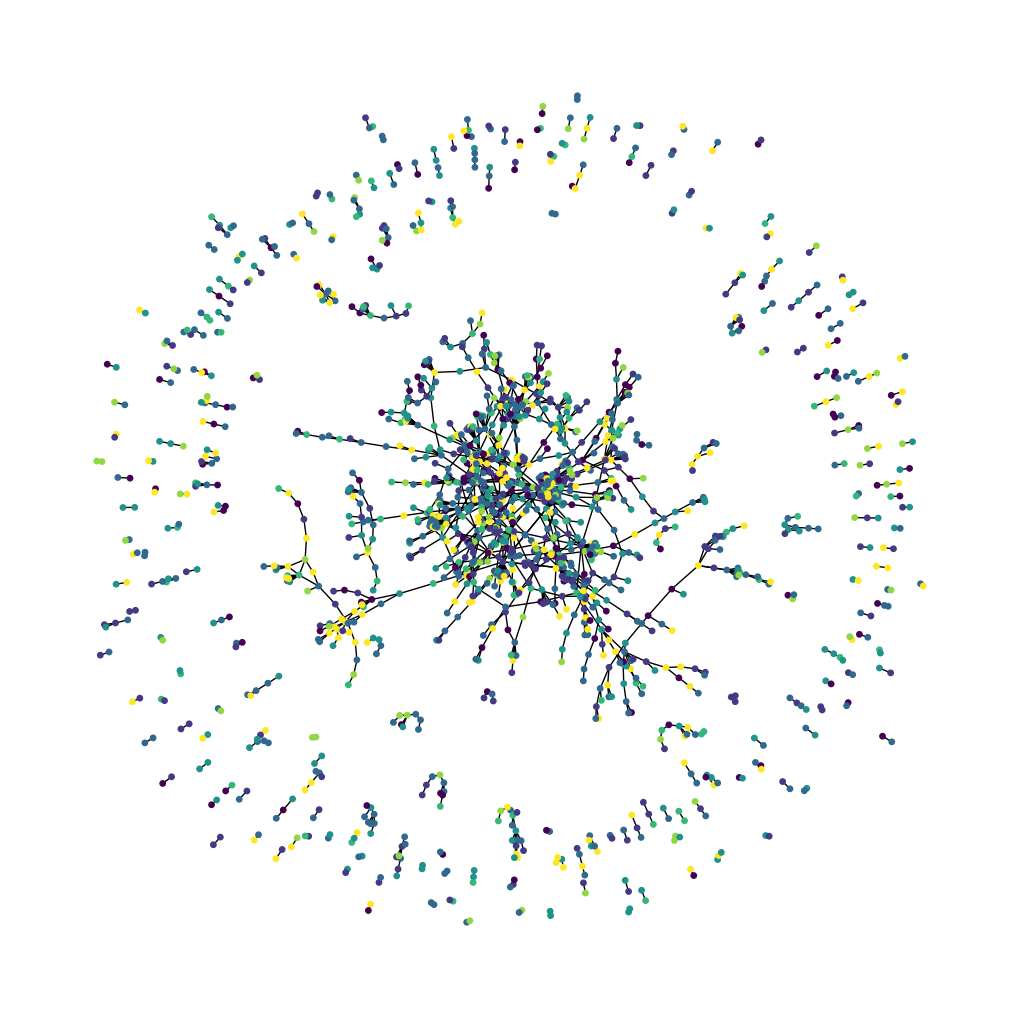

In [17]:
# import nx
import networkx as nx

plt.figure(figsize=(10, 10))
colors = papers["subject"].tolist()
cora_graph = nx.from_pandas_edgelist(citations.sample(n=1500))
subjects = list(papers[papers["paper_id"].isin(list(cora_graph.nodes))]["subject"])
nx.draw_spring(cora_graph, node_size=15, node_color=subjects)

In [25]:
train_data, test_data = [], []

for _, group_data in papers.groupby("subject"):
    # Select around 50% of the dataset for training.
    random_selection = np.random.rand(len(group_data.index)) <= 0.5
    train_data.append(group_data[random_selection])
    test_data.append(group_data[~random_selection])

train_data = pd.concat(train_data).sample(frac=1)
test_data = pd.concat(test_data).sample(frac=1)

print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

Train data shape: (1351, 1435)
Test data shape: (1357, 1435)


In [26]:
hidden_units = [32, 32]
learning_rate = 0.01
dropout_rate = 0.5
num_epochs = 300
batch_size = 256

In [27]:
def run_experiment(model, x_train, y_train):
    # Compile the model.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
    )
    # Create an early stopping callback.
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # Monitor validation loss
        patience=100,       # Increased patience
        restore_best_weights=True,
    )
    # Fit the model.
    history = model.fit(
        x=x_train,
        y=y_train,
        epochs=num_epochs,
        batch_size=batch_size,
        validation_split=0.15,
        callbacks=[early_stopping],
    )

    return history

In [28]:
def display_learning_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history["loss"])
    ax1.plot(history.history["val_loss"])
    ax1.legend(["train", "test"], loc="upper right")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")

    ax2.plot(history.history["acc"])
    ax2.plot(history.history["val_acc"])
    ax2.legend(["train", "test"], loc="upper right")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    plt.show()

In [29]:
def create_ffn(hidden_units, dropout_rate, name=None):
    fnn_layers = []

    for units in hidden_units:
        fnn_layers.append(layers.BatchNormalization())
        fnn_layers.append(layers.Dropout(dropout_rate))
        fnn_layers.append(layers.Dense(units, activation=tf.nn.gelu))

    return keras.Sequential(fnn_layers, name=name)

In [30]:
feature_names = list(set(papers.columns) - {"paper_id", "subject"})
num_features = len(feature_names)
num_classes = len(class_idx)

# Create train and test features as a numpy array.
x_train = train_data[feature_names].to_numpy()
x_test = test_data[feature_names].to_numpy()
# Create train and test targets as a numpy array.
y_train = train_data["subject"]
y_test = test_data["subject"]

## 1.2 *(1 point)* Implement the DNN-based edge prediction model. 

In [31]:
# import layers from tf
from tensorflow.keras import layers

def create_baseline_model(hidden_units, num_classes, dropout_rate=0.2):
    inputs = layers.Input(shape=(num_features,), name="input_features")
    x = create_ffn(hidden_units, dropout_rate, name=f"ffn_block1")(inputs)
    for block_idx in range(4):
        # Create an FFN block.
        x1 = create_ffn(hidden_units, dropout_rate, name=f"ffn_block{block_idx + 2}")(x)
        # Add skip connection.
        x = layers.Add(name=f"skip_connection{block_idx + 2}")([x, x1])
    # Compute logits.
    logits = layers.Dense(num_classes, name="logits")(x)
    # Create the model.
    return keras.Model(inputs=inputs, outputs=logits, name="baseline")


baseline_model = create_baseline_model(hidden_units, num_classes, dropout_rate)
baseline_model.summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 1433)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_block1          │ (None, 32)        │     52,804 │ input_features[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_block2          │ (None, 32)        │      2,368 │ ffn_block1[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_connection2    │ (None, 32)        │          0 │ ffn_block1[0][0], │
│ (Add)               │                   │            │ ffn_block2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_block3          │ (None, 32)        │      2,368 │ skip_connection2… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_connection3    │ (None, 32)        │          0 │ skip_connection2… │
│ (Add)               │                   │            │ ffn_block3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_block4          │ (None, 32)        │      2,368 │ skip_connection3… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_connection4    │ (None, 32)        │          0 │ skip_connection3… │
│ (Add)               │                   │            │ ffn_block4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_block5          │ (None, 32)        │      2,368 │ skip_connection4… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_connection5    │ (None, 32)        │          0 │ skip_connection4… │
│ (Add)               │                   │            │ ffn_block5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logits (Dense)      │ (None, 7)         │        231 │ skip_connection5… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 62,507 (244.17 KB)

 Trainable params: 59,065 (230.72 KB)

 Non-trainable params: 3,442 (13.45 KB)

In [32]:
history = run_experiment(baseline_model, x_train, y_train)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - acc: 0.1979 - loss: 3.7025 - val_acc: 0.1675 - val_loss: 2.0042
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - acc: 0.1609 - loss: 2.6698 - val_acc: 0.1675 - val_loss: 1.9571
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.2465 - loss: 2.3587 - val_acc: 0.1773 - val_loss: 1.9291
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - acc: 0.2643 - loss: 2.0943 - val_acc: 0.1527 - val_loss: 1.9091
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.2503 - loss: 2.0301 - val_acc: 0.2808 - val_loss: 1.8963
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.2910 - loss: 1.8570 - val_acc: 0.2759 - val_loss: 1.8895
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.3226 - loss: 1.8251 - val_acc: 0.3251 - val_loss: 1.8742
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.3123 - loss: 1.7747 - val_acc: 0.4433 - val_loss: 1.8452
Epoch 9/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.3416 - loss: 1

In [ ]:
_, test_accuracy = baseline_model.evaluate(x=x_test, y=y_test, verbose=0)
print(f"Test accuracy: {round(test_accuracy * 100, 2)}%")

Test accuracy: 73.47%


## 1.3 *(3 points)* Implement the GNN-based edge prediction model.

In [37]:
# Set train, validation, and test ratios
train_data, val_data, test_data = [], [], []
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Set random seed to get the same training set and test set in different running times.
np.random.seed(0)

# Select training_ratio from each group of paper subject to form the training set
for _, group_data in papers.groupby("subject"):
    # Get a random list of probabilities from a subject group
    random_probs = np.random.rand(len(group_data.index))

    # Split into train, val, and test
    random_selection_train = random_probs <= train_ratio
    random_selection_val = (train_ratio < random_probs) & (random_probs <= train_ratio + val_ratio)
    random_selection_test = 1 - test_ratio < random_probs

    # Add group DataFrames containing paper indices to training, validation and test sets
    train_data.append(group_data[random_selection_train])
    val_data.append(group_data[random_selection_val])
    test_data.append(group_data[random_selection_test])

# Concat list of DataFrames to a big DataFrame for training and test dataset
train_data = pd.concat(train_data)
val_data = pd.concat(val_data)
test_data = pd.concat(test_data)

print("Training set:", train_data.shape)
print("Validation set:", val_data.shape)
print("Test set:", test_data.shape)

# List of features (word attributes) of a paper (node)
feature_names = set(papers.columns) - {"paper_id", "subject"}

# Create tensors of data samples
x_train = train_data[list(feature_names)].to_numpy()
x_val = val_data[list(feature_names)].to_numpy()
x_test = test_data[list(feature_names)].to_numpy()

# Create tensors of data labels
y_train = train_data["subject"]
y_val = val_data["subject"]
y_test = test_data["subject"]

# Number of features (word attributes) of a paper (node)
num_features = len(feature_names)

# Number of labels (subjects) of a paper
num_classes = len(class_idx)

# --

# Graph information contains:
# - Node information.
# - Edge information.

# Node information: is an array of node features of shape [num_nodes, num_features].
node_features = tf.cast(papers.sort_values("paper_id")[list(feature_names)].to_numpy(), dtype=tf.dtypes.float32)

# Edge information: is an array of edges (sparse adjacency matrix) of shape [2, num_edges].
edges = citations[["source", "target"]].to_numpy().T

# Create graph info tuple with node information and edge information
graph_info = (node_features, edges)

print("Node features shape:", node_features.shape)
print("Edges shape:", edges.shape)

# Define a custom layer by extending the base class tensorflow.keras.layers.Layer
# Reference: https://keras.io/api/layers/base_layer/
class GNNLayer(layers.Layer):
    # Define a graph convolutional layer consisting of two operations:
    # - aggregate: sum of embeddings of neighbor nodes of a node.
    # - update: the node's embedding is updated by adding to aggregation result.

    # Defines custom layer attributes in __init__()
    def __init__(self, hidden_units_ffn, dropout_rate_ffn):
        # Inherit parent class initialization
        super().__init__()

        # Prepare the messages of neighbours, i.e., neighbour_messages
        self.ffn_prepare = create_ffn(hidden_units_ffn, dropout_rate_ffn)

        # Update the node embedding with the neighbour messages
        self.update_fn = create_ffn(hidden_units_ffn, dropout_rate_ffn)

    # Aggregate (sum) embeddings of neighbor nodes of a node
    # This aggregation can be sum, concat, mean, etc. In this sample code, we choose 'sum'.
    def aggregate(self, neighbour_messages, node_indices, node_embeddings):
        # Get number of nodes in the graph
        num_nodes = node_embeddings.shape[0]

        # Aggregate (sum) embeddings of neighbor nodes of all nodes; put results in a vector
        aggregated_message = tf.math.unsorted_segment_sum(neighbour_messages, node_indices, num_segments=num_nodes)

        # Return embedding result after aggregation
        return aggregated_message

    # Aggregation result from neighbors is added to the node's embedding to update the node
    def update(self, node_embeddings, aggregated_messages):
        # Add neighbors' embeddings to current node's embeddings, followed by a processing function (i.e., a feed forward network).
        node_embeddings = self.update_fn(node_embeddings + aggregated_messages)

        # Normalizes node embeddings to unit vectors, i.e., np.sum(node_embeddings[k]**2) = 1.0
        node_embeddings = tf.nn.l2_normalize(node_embeddings, axis=1)

        return node_embeddings

    # Function call() performs the logic of applying the layer to the input
    # Reference: https://keras.io/guides/making_new_layers_and_models_via_subclassing/
    def call(self, input_graph_info):
        # Process the input to produce the node_embeddings.
        # input (i.e., graph_info): a tuple of two elements: node_embeddings and edges
        # Returns: node_embeddings of shape [num_nodes, embedding_dim].

        # Extract node embeddings and edges from inputs, i.e., graph_info
        node_embeddings, edges = input_graph_info

        # Get source node indices and target neighbour indices from edges.
        source_node_indices, target_neighbour_indices = edges[0], edges[1]

        # Gather node embeddings of all target neighbours by their indices
        # neighbour_embeddings shape is [num_edges, embedding_dim]
        neighbour_embeddings = tf.gather(node_embeddings, target_neighbour_indices)

        # Prepare target neighbour embeddings by getting them through FFN (for complexity) to produce aggregation message
        neighbour_messages = self.ffn_prepare(neighbour_embeddings)

        # Aggregate the neighbour messages according to the current nodes, i.e., source_node_indices
        aggregated_messages = self.aggregate(neighbour_messages, source_node_indices, node_embeddings)

        # Update the current nodes with the aggregated messages.
        return self.update(node_embeddings, aggregated_messages)

# import layers
from tensorflow.keras import layers

# Define a custom model by extending the base class tensorflow.keras.Model
# Reference: https://keras.io/api/models/model/
class GNNModel(tf.keras.Model):
    # Implement model architecture in __init()__ function
    def __init__(self, node_features, edges, num_classes, hidden_units_ffn, dropout_rate_ffn):
        # Inherit parent class initialization
        super().__init__()

        # Unpack graph_info into node_features and edges
        self.node_features = node_features
        self.edges = edges
        self.num_classes = num_classes
        self.hidden_units_ffn = hidden_units_ffn
        self.dropout_rate_ffn = dropout_rate_ffn

        # Create a process layer.
        self.preprocess = create_ffn(self.hidden_units_ffn, self.dropout_rate_ffn)

        # Create the first GraphConv layer.
        self.conv1 = GNNLayer(self.hidden_units_ffn, self.dropout_rate_ffn)

        # Create the second GraphConv layer.
        self.conv2 = GNNLayer(self.hidden_units_ffn, self.dropout_rate_ffn)

        # Create a postprocess layer.
        self.postprocess = create_ffn(self.hidden_units_ffn, self.dropout_rate_ffn)

        # Create a classification layer.
        self.classify = layers.Dense(units=self.num_classes, activation=tf.nn.softmax,
                                      # Add kernel_regularizer for weight decay
                                      kernel_regularizer=tf.keras.regularizers.l2(0.01))

    # Implement the model's forward pass in call() function
    # input_node_indices is the list of nodes in x_train or x_test split
    def call(self, input_node_indices):
        # Ensure input_node_indices is a tensor
        if isinstance(input_node_indices, (list, tuple)):
            input_node_indices = tf.convert_to_tensor(input_node_indices, dtype=tf.int32)
        elif not isinstance(input_node_indices, tf.Tensor):
            raise ValueError("input_node_indices must be a list, tuple, or tf.Tensor")

        # Preprocess the node_features to produce node representations.
        x0 = self.preprocess(self.node_features)

        # Apply the first graph conv layer.
        x1 = self.conv1((x0, self.edges))

        # Skip connection.
        x2 = x1 + x0

        # Apply the second graph conv layer.
        x3 = self.conv2((x2, self.edges))

        # Skip connection.
        x4 = x3 + x2

        # Postprocess node embedding
        x5 = self.postprocess(x4)

        # Fetch node embeddings for the input_node_indices.
        node_embeddings = tf.gather(x5, input_node_indices)

        # Compute classification output of node embeddings of input_node_indices
        return self.classify(node_embeddings)

gnn_model = GNNModel(
    node_features=graph_info[0],  # contains node features
    edges=graph_info[1],  # contains edges
    num_classes=num_classes,
    hidden_units_ffn=hidden_units,
    dropout_rate_ffn=dropout_rate
)

# Instantiate and build the model on an arbitrary data sample: input_node_indices = [1], i.e. consisting of node index = 1
gnn_model(tf.constant([1]))

# Print model architecture
gnn_model.summary()

# Prepare input_node_indices of x_train, x_val and x_test.
# These variables contain list of node indices belonging to training, validation and test set.
x_train_gnn = train_data.paper_id.to_numpy()
x_val_gnn = val_data.paper_id.to_numpy()
x_test_gnn = test_data.paper_id.to_numpy()

# Compile the DNN model
gnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
)

# Implement early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=15,  # Increased patience to 15 epochs
    restore_best_weights=True  # Restore the best model weights
)

# Define learning rate scheduler
def lr_scheduler(epoch, lr):
    if epoch % 20 == 0 and epoch > 0:  # Reduce learning rate every 20 epochs
        return lr * 0.5
    else:
        return lr

# Implement learning rate scheduling
lr_schedule_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# Train and validate the DNN model with early stopping and learning rate scheduling
history_gnn = gnn_model.fit(
    x=x_train_gnn,
    y=y_train,
    epochs=100,
    batch_size=1024,
    validation_data=(x_val_gnn, y_val),
    callbacks=[early_stopping, lr_schedule_callback]  # Add both callbacks
)

gnn_model_eval = gnn_model.evaluate(x_test_gnn, y_test)
print("List of metrics" + str(gnn_model.metrics_names))  # List of possible metrics of the model evaluation, this is the metrics specified in the model.compile().
print("Test loss: " + str(gnn_model_eval[0]))
print("Test accuracy: " + str(gnn_model_eval[1]))

Training set: (1863, 1435)
Validation set: (405, 1435)
Test set: (440, 1435)
Node features shape: (2708, 1433)
Edges shape: (2, 5429)


Model: "gnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (2708, 32)             │        52,804 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gnn_layer (GNNLayer)            │ ?                      │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gnn_layer_1 (GNNLayer)          │ ?                      │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (2708, 32)             │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (1, 7)                 │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,875 (253.42 KB)

 Trainable params: 61,305 (239.47 KB)

 Non-trainable params: 3,570 (13.95 KB)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - acc: 0.1991 - loss: 2.0222 - val_acc: 0.3160 - val_loss: 1.9684 - learning_rate: 0.0100
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - acc: 0.2903 - loss: 1.9285 - val_acc: 0.3160 - val_loss: 1.8180 - learning_rate: 0.0100
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - acc: 0.2978 - loss: 1.8331 - val_acc: 0.3506 - val_loss: 1.6795 - learning_rate: 0.0100
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - acc: 0.3553 - loss: 1.6268 - val_acc: 0.4395 - val_loss: 1.5213 - learning_rate: 0.0100
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - acc: 0.5390 - loss: 1.3750 - val_acc: 0.6074 - val_loss: 1.2300 - learning_rate: 0.0100
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - acc: 0.6535 - loss: 1.0911 - val_acc: 0.6074 - val_loss: 1.1038 - learning_rate: 0.0100
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - acc: 0.6774 - loss: 0.8891 - val_acc: 0.6395 - val_loss: 1.1013 - learning_rate: 0.0100
Epoch 8/100
2/2 ━━━

In [38]:
x_test = test_data.paper_id.to_numpy()
_, test_accuracy = gnn_model.evaluate(x=x_test, y=y_test, verbose=0)
print(f"Test accuracy: {round(test_accuracy * 100, 2)}%")

Test accuracy: 73.86%


## 1.4 *(0.5 points)* Train and evaluate both models, computing the necessary metrics.  

### DNN

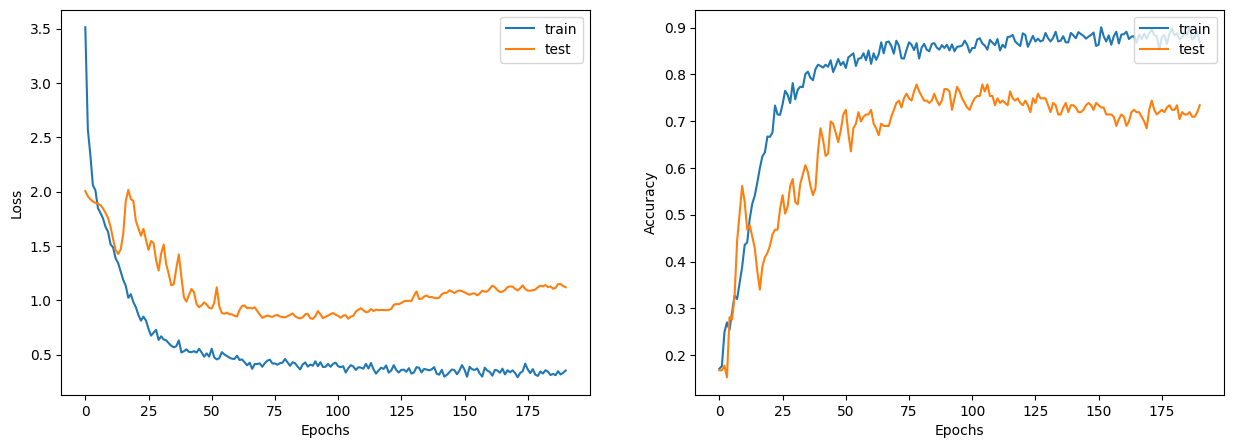

In [33]:
display_learning_curves(history)

In [35]:
def generate_random_instances(num_instances):
    token_probability = x_train.mean(axis=0)
    instances = []
    for _ in range(num_instances):
        probabilities = np.random.uniform(size=len(token_probability))
        instance = (probabilities <= token_probability).astype(int)
        instances.append(instance)

    return np.array(instances)


def display_class_probabilities(probabilities):
    for instance_idx, probs in enumerate(probabilities):
        print(f"Instance {instance_idx + 1}:")
        for class_idx, prob in enumerate(probs):
            print(f"- {class_values[class_idx]}: {round(prob * 100, 2)}%")

In [36]:
new_instances = generate_random_instances(num_classes)
logits = baseline_model.predict(new_instances)
probabilities = keras.activations.softmax(tf.convert_to_tensor(logits)).numpy()
display_class_probabilities(probabilities)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 925ms/step
Instance 1:
- 0: 0.029999999329447746%
- 1: 0.12999999523162842%
- 2: 0.8600000143051147%
- 3: 98.83999633789062%
- 4: 0.09000000357627869%
- 5: 0.009999999776482582%
- 6: 0.03999999910593033%
Instance 2:
- 0: 1.659999966621399%
- 1: 10.15999984741211%
- 2: 39.83000183105469%
- 3: 9.600000381469727%
- 4: 2.4100000858306885%
- 5: 3.200000047683716%
- 6: 33.150001525878906%
Instance 3:
- 0: 4.0%
- 1: 1.899999976158142%
- 2: 21.989999771118164%
- 3: 1.6299999952316284%
- 4: 49.150001525878906%
- 5: 3.109999895095825%
- 6: 18.219999313354492%
Instance 4:
- 0: 1.6699999570846558%
- 1: 2.4000000953674316%
- 2: 47.72999954223633%
- 3: 9.729999542236328%
- 4: 4.239999771118164%
- 5: 3.740000009536743%
- 6: 30.5%
Instance 5:
- 0: 0.15000000596046448%
- 1: 93.19999694824219%
- 2: 0.8799999952316284%
- 3: 4.199999809265137%
- 4: 0.1599999964237213%
- 5: 0.019999999552965164%
- 6: 1.3899999856948853%
Instance 6:
- 0: 0.9900000095367432%
- 1: 7.929999828338623

### GNN

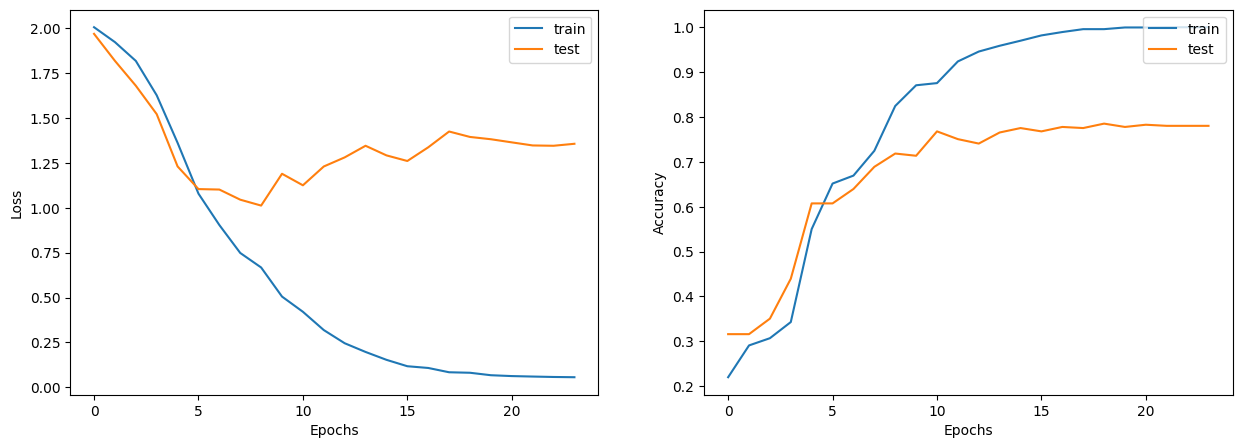

In [39]:
# display the learning curves
display_learning_curves(history_gnn)

In [40]:
# First we add the N new_instances as nodes to the graph
# by appending the new_instance to node_features.
num_nodes = node_features.shape[0]
new_node_features = np.concatenate([node_features, new_instances])
# Second we add the M edges (citations) from each new node to a set
# of existing nodes in a particular subject
new_node_indices = [i + num_nodes for i in range(num_classes)]
new_citations = []
for subject_idx, group in papers.groupby("subject"):
    subject_papers = list(group.paper_id)
    # Select random x papers specific subject.
    selected_paper_indices1 = np.random.choice(subject_papers, 5)
    # Select random y papers from any subject (where y < x).
    selected_paper_indices2 = np.random.choice(list(papers.paper_id), 2)
    # Merge the selected paper indices.
    selected_paper_indices = np.concatenate(
        [selected_paper_indices1, selected_paper_indices2], axis=0
    )
    # Create edges between a citing paper idx and the selected cited papers.
    citing_paper_indx = new_node_indices[subject_idx]
    for cited_paper_idx in selected_paper_indices:
        new_citations.append([citing_paper_indx, cited_paper_idx])

new_citations = np.array(new_citations).T
new_edges = np.concatenate([edges, new_citations], axis=1)

In [41]:
print("Original node_features shape:", gnn_model.node_features.shape)
print("Original edges shape:", gnn_model.edges.shape)
gnn_model.node_features = new_node_features
gnn_model.edges = new_edges
gnn_model.edge_weights = tf.ones(shape=new_edges.shape[1])
print("New node_features shape:", gnn_model.node_features.shape)
print("New edges shape:", gnn_model.edges.shape)

logits = gnn_model.predict(tf.convert_to_tensor(new_node_indices))
probabilities = keras.activations.softmax(tf.convert_to_tensor(logits)).numpy()
display_class_probabilities(probabilities)

Original node_features shape: (2708, 1433)
Original edges shape: (2, 5429)
New node_features shape: (2715, 1433)
New edges shape: (2, 5478)
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Instance 1:
- 0: 14.25%
- 1: 12.1899995803833%
- 2: 24.040000915527344%
- 3: 13.319999694824219%
- 4: 12.079999923706055%
- 5: 12.0600004196167%
- 6: 12.050000190734863%
Instance 2:
- 0: 17.170000076293945%
- 1: 14.369999885559082%
- 2: 15.760000228881836%
- 3: 13.029999732971191%
- 4: 12.720000267028809%
- 5: 13.449999809265137%
- 6: 13.510000228881836%
Instance 3:
- 0: 13.630000114440918%
- 1: 12.109999656677246%
- 2: 24.100000381469727%
- 3: 13.09000015258789%
- 4: 12.579999923706055%
- 5: 12.229999542236328%
- 6: 12.260000228881836%
Instance 4:
- 0: 11.65999984741211%
- 1: 11.550000190734863%
- 2: 30.280000686645508%
- 3: 11.819999694824219%
- 4: 11.579999923706055%
- 5: 11.550000190734863%
- 6: 11.5600004196167%
Instance 5:
- 0: 15.050000190734863%
- 1: 17.81999969482422%
- 2: 12.6899995803833%
- 3: 13.11999

## 2. Open discussion questions

In [ ]:
# 2.1 *(1 point)* Discuss your approach to formulating the edge prediction problem for both DNN and GNN.
# Answer:
# The edge prediction problem can be formulated as a binary classification task where the goal is to predict whether an edge exists between two nodes (papers) in the graph.
# For the DNN model, use the features of the two nodes as input and train a binary classifier to predict the existence of an edge between them. The DNN model learns to capture the relationships between node features and edge existence.
# For the GNN model, leverage the graph structure by using the node features and the adjacency information to learn a representation of the entire graph. The GNN model can then predict edges based on the learned representations of the nodes and their neighbors.

In [ ]:
# 2.2 *(1 point)* How do the performance results of DNN and GNN compare? What are the advantages of using GNN for edge prediction?
# Answer:
# The performance results of DNN and GNN can vary depending on the dataset and the specific architecture used. In general, GNNs tend to outperform DNNs for edge prediction tasks on graph-structured data.
# The advantages of using GNN for edge prediction include:
# - GNNs can capture the local and global structure of the graph, allowing them to learn more meaningful representations of nodes and edges.
# - GNNs can leverage the connectivity information of the graph, which is crucial for edge prediction tasks.
# - GNNs can handle varying node degrees and graph topologies, making them more flexible for different types of graphs.
# However, from my experience, the complexity of GNNs makes it harder to train and tune compared to DNNs. GNNs also require more computational resources due to the graph structure and message-passing operations. And it is easier to overfit. Hence, GNNs are not always the best choice for edge prediction tasks, especially when the dataset is small or the graph structure is simple.

In [ ]:
# 2.3 *(1 point)* How does the graph structure of the Cora dataset influence your approach with the GNN?
# Answer:
# The graph structure of the Cora dataset, which consists of papers and their citations, influences the GNN approach in several ways:
# - The GNN can leverage the citation relationships between papers to learn meaningful representations of nodes based on their neighbors.
# - The GNN can capture the local structure of the graph, allowing it to learn from the connectivity patterns of papers within the same subject.
# - The GNN can handle the varying degrees of nodes, as some papers may have many citations while others may have few.

In [ ]:
# 2.4 *(1 point)* How do you think your models would scale to larger graph datasets? Would you face any challenges?
# Answer:
# Scaling the models to larger graph datasets may present several challenges:
# - Memory consumption: Larger graphs may require more memory to store node features and edges, which can lead to out-of-memory errors.
# - Computational complexity: The time complexity of GNNs can increase with the number of nodes and edges, leading to longer training times.
# - Overfitting: Larger datasets may lead to overfitting, especially if the model is too complex or if there is insufficient training data.
# To address these challenges, we can consider using techniques such as mini-batch training, graph sampling, and distributed training to handle larger datasets more efficiently.

In [ ]:
# 2.5 *(1 point)* What were the main challenges in implementing and training these models? How did you address them?
# Answer:
# - Overfitting: The models, particularly the GNN, tended to overfit to the training data due to the relatively small size of the Cora dataset and the complexity of the models.
# - Manual Data Download: The requirement to manually download the Cora dataset added an extra step to the process and could potentially introduce errors if not handled carefully.
# - Framework Updates: Changes in Keras and TensorFlow APIs between the original paper's implementation and the current versions made it necessary to adapt the code, which could be time-consuming and error-prone.
# - Convergence Issues: These framework updates and code adaptations sometimes led to convergence issues during training, requiring further adjustments to hyperparameters or model architecture.
# To address these challenges, I used techniques such as data augmentation, grid search for hyperparameter tuning, add drop out, and early stopping to prevent overfitting and ensure convergence.
# Also, adjust the order of batch normalization and dropout layers in the create_ffn function to provide a better optimization flow.
# However, the result is still not very good, and need to be improved.